# 0. Configuration

In [29]:
import pandas as pd
import numpy as np
from scipy.optimize import minimize,Bounds,minimize_scalar
import statsmodels

import matplotlib.pyplot as plt
import seaborn as sns

# model preparation
from sklearn.model_selection import train_test_split

# modeling
import xgboost as xgb
from sklearn.model_selection import GroupShuffleSplit, GroupKFold, RandomizedSearchCV

# evaluation
from sklearn.metrics import roc_auc_score, average_precision_score
from scipy.stats import randint, uniform


# 1. Load Data

In [2]:
search_df = pd.read_csv('search_marketplace.csv')
search_df.head()

,srch_id,date_time,site_id,visitor_location_country_id,visitor_hist_starrating,visitor_hist_adr_usd,prop_country_id,prop_id,prop_starrating,prop_review_score,...,comp6_rate_percent_diff,comp7_rate,comp7_inv,comp7_rate_percent_diff,comp8_rate,comp8_inv,comp8_rate_percent_diff,click_bool,gross_bookings_usd,booking_bool
0,1,4/4/2013 8:32,12,187,NaN,NaN,219,893,3,3.5,...,NaN,NaN,NaN,NaN,0.0,0.0,NaN,0,NaN,0
1,1,4/4/2013 8:32,12,187,NaN,NaN,219,10404,4,4.0,...,NaN,NaN,NaN,NaN,0.0,0.0,NaN,0,NaN,0
2,1,4/4/2013 8:32,12,187,NaN,NaN,219,21315,3,4.5,...,NaN,NaN,NaN,NaN,0.0,0.0,NaN,0,NaN,0
3,1,4/4/2013 8:32,12,187,NaN,NaN,219,27348,2,4.0,...,NaN,NaN,NaN,NaN,-1.0,0.0,5.0,0,NaN,0
4,1,4/4/2013 8:32,12,187,NaN,NaN,219,29604,4,3.5,...,NaN,NaN,NaN,NaN,0.0,0.0,NaN,0,NaN,0


# 2. Train Test Split

In [ ]:
# define X and y
X= search_df.drop(columns=['click_bool','gross_bookings_usd','booking_bool','date_time'])
y = search_df['click_bool']

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)

In [13]:
X_train

,srch_id,site_id,visitor_location_country_id,visitor_hist_starrating,visitor_hist_adr_usd,prop_country_id,prop_id,prop_starrating,prop_review_score,prop_brand_bool,...,comp5_rate_percent_diff,comp6_rate,comp6_inv,comp6_rate_percent_diff,comp7_rate,comp7_inv,comp7_rate_percent_diff,comp8_rate,comp8_inv,comp8_rate_percent_diff
153248,10271,5,219,NaN,NaN,219,109257,2,4.0,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
67802,4525,5,219,NaN,NaN,219,47167,3,5.0,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,NaN
148889,9983,16,31,NaN,NaN,31,15920,2,4.5,0,...,9.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
103093,6898,5,35,3.46,72.16,35,84978,4,4.5,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
104681,7011,5,219,NaN,NaN,100,132210,4,4.0,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119879,7993,5,219,NaN,NaN,219,54075,3,3.5,1,...,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
103694,6944,32,220,NaN,NaN,219,21315,3,4.5,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,NaN
131932,8825,5,219,NaN,NaN,219,135390,2,4.0,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
146867,9853,14,100,NaN,NaN,219,2906,3,4.0,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,NaN


In [14]:
y_train.info()

<class 'pandas.core.series.Series'>
Index: 160000 entries, 153248 to 121958
Series name: click_bool
Non-Null Count   Dtype
--------------   -----
160000 non-null  int64
dtypes: int64(1)
memory usage: 2.4 MB


# 3. XGBoost - No Hyperparameter Tuning

In [15]:
# Train in the clear and quantize the weights
model = xgb.XGBClassifier()
model.fit(X_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [16]:
eval_test=model.predict(X_test)

In [ ]:
# roc; useful for false positives
auc = roc_auc_score(y_test, eval_test)
ap  = average_precision_score(y_test, eval_test)

print(f"Test ROC-AUC: {auc:.4f}")
print(f"Test Avg Precision (PR-AUC): {ap:.4f}")

Test ROC-AUC: 0.5071
Test Avg Precision (PR-AUC): 0.0494


In [22]:
# see feature importance

pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False).head(10)

position                0.158420
random_bool             0.037828
comp1_inv               0.032710
prop_location_score2    0.024545
srch_room_count         0.024496
prop_starrating         0.022344
price_usd               0.021395
promotion_flag          0.021344
prop_location_score1    0.020203
comp6_rate              0.019123
dtype: float32

<Axes: >

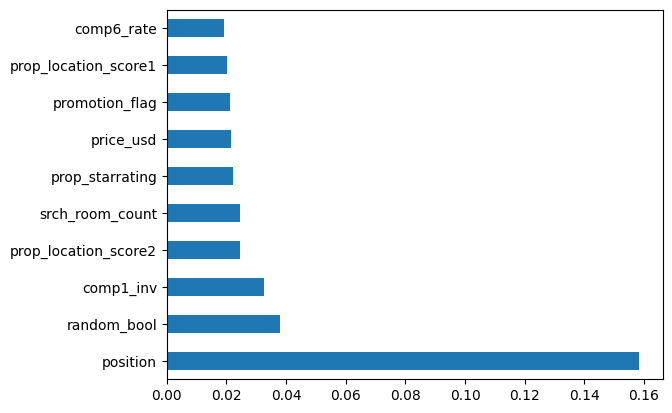

In [27]:
# plot feature importance
pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False).head(10).plot(kind='barh')

# 4. XGBoost - Fine Tuning

In [36]:
# groups for split / CV
groups = search_df['srch_id']

# holdout split by search session
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=groups))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
groups_train = groups.iloc[train_idx]

# class imbalance helper
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

base_model = xgb.XGBClassifier(
    objective="binary:logistic",
    eval_metric="auc",
    tree_method="hist",
    random_state=42,
    scale_pos_weight=scale_pos_weight
)

param_dist = {
    "n_estimators": randint(200, 800),
    "max_depth": randint(3, 10),
    "learning_rate": uniform(0.01, 0.2),
    "subsample": uniform(0.6, 0.4),
    "colsample_bytree": uniform(0.6, 0.4),
    "min_child_weight": randint(1, 10),
    "gamma": uniform(0, 5),
    "reg_alpha": uniform(0, 2),
    "reg_lambda": uniform(0.5, 3)
}

cv = GroupKFold(n_splits=3)

search = RandomizedSearchCV(
    estimator=base_model,
    param_distributions=param_dist,
    n_iter=10,
    scoring="roc_auc",
    cv=cv,
    verbose=1,
    n_jobs=-1,
    random_state=42
)

search.fit(X_train, y_train, groups=groups_train)

best_model = search.best_estimator_

print("Best params:")
print(search.best_params_)

Fitting 3 folds for each of 10 candidates, totalling 30 fits


/Users/chohasong/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (
/Users/chohasong/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (
/Users/chohasong/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (
/Users/chohasong/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (
/Users/chohasong/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:61: UserWar

Best params:
{'colsample_bytree': 0.8469926038510867, 'gamma': 3.0582658024414044, 'learning_rate': 0.011413261043943482, 'max_depth': 3, 'min_child_weight': 1, 'n_estimators': 674, 'reg_alpha': 1.223705789444759, 'reg_lambda': 0.9184815819561255, 'subsample': 0.7168578594140873}


In [37]:
y_prob = best_model.predict_proba(X_test)[:, 1]
print("Test ROC AUC:", roc_auc_score(y_test, y_prob))
print("Test PR AUC:", average_precision_score(y_test, y_prob))


Test ROC AUC: 0.760651535945549
Test PR AUC: 0.15351133840629944
